# Scoring Real Locations: Worked Examples

Uses the models trained above to score real counties, showing how the scorer adapts to how much the caller actually knows about a site.

### Docstring, imports, setup

In [1]:
"""
predict_location.py — score a location, choosing the model variant that matches the inputs
the user actually supplied.

    from predict_location import predict, print_prediction

    print_prediction(fips='51047', by_right=0, industrial_zoned=1,
                     build_converted=0, project_year=2026)
    print_prediction(county='Culpeper', state='VA')          # county-only screen

WHY VARIANT SELECTION MATTERS
by_right, industrial_zoned and build_converted all carry NEGATIVE coefficients and
PROTECTIVE training medians. Scoring a full model with them missing therefore imputes the
protective case and biases the estimate DOWNWARD — the site looks safer than the evidence
supports. Rather than impute-and-warn, this dispatches to a variant FIT WITHOUT the missing
predictors, so the model matches the information available.

    all four site inputs supplied      -> FULL
    project_year but no zoning inputs  -> NO_ZONING
    neither                            -> COUNTY_ONLY

Partial zoning input (e.g. industrial_zoned known, by_right not) still routes to NO_ZONING:
a variant exists per input SET, not per individual field, and using FULL with one of three
missing reintroduces the same downward bias.

M2 is conditional on opposition having occurred and is only reported when explicitly asked
for, or when M1 already indicates opposition is likely.

DEFAULT OUTPUT IS M1 + M4, NOT M1/M3/M4. M3 ("any adverse outcome, any cause") is near-chance
on the population that actually gets queried (AUC 0.55 on the 2026 cohort) because ~40% of
its positives are non-opposition failures (financing, market) the opposition-focused
predictors can't explain. It is still computed internally whenever M4 is requested, purely to
enforce `M4 <= min(M1, M3)` — pass `models=(..., 'M3')` explicitly to see it. See
PREDICTION_STACK.md, "The cohort-drift finding".
"""
from __future__ import annotations
from pathlib import Path
import pickle
import numpy as np
import pandas as pd

HERE = Path('.').resolve()
ZONING = ['by_right', 'industrial_zoned', 'build_converted']
SITE = ZONING + ['project_year']
EPS = 1e-6

_scen = _feat = None

### Load artifacts, choose variant, resolve county

In [2]:
def _load():
    global _scen, _feat
    if _scen is None:
        _scen = pickle.load(open(HERE / 'scenario_models.pkl', 'rb'))
    if _feat is None:
        f = pd.read_csv(HERE / 'county_prediction_features.csv', dtype={'fips': str}, low_memory=False)
        f['fips'] = f['fips'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(5)
        _feat = f[f.fips.notna()].drop_duplicates('fips').set_index('fips')
    return _scen, _feat


def choose_variant(site: dict) -> tuple[str, list]:
    """Return (variant name, list of missing site inputs)."""
    missing = [k for k in SITE if site.get(k) is None or (isinstance(site.get(k), float) and np.isnan(site[k]))]
    have_zoning = not any(k in missing for k in ZONING)
    have_year = 'project_year' not in missing
    if have_zoning and have_year:
        return 'FULL', missing
    if have_year:
        return 'NO_ZONING', missing
    return 'COUNTY_ONLY', missing


def county_row(fips=None, county=None, state=None) -> dict:
    _, feat = _load()
    if fips:
        k = str(fips).split('.')[0].zfill(5)
        if k not in feat.index:
            raise KeyError(f'county FIPS {k} not in the feature table')
        r = feat.loc[k].to_dict(); r['fips'] = k
        return r
    if county and state:
        cand = feat[(feat.county.astype(str).str.strip().str.lower() == str(county).strip().lower()) &
                    (feat.state.astype(str).str.strip().str.upper() == str(state).strip().upper())]
        if cand.empty:
            raise KeyError(f'county {county}, {state} not found')
        r = cand.iloc[0].to_dict(); r['fips'] = cand.index[0]
        return r
    raise ValueError('provide fips, or county and state')

### Score a facility against one model, then the full dispatcher

In [3]:
def _score(entry, facility) -> dict:
    # YEAR CAP. project_year enters M1/M3/M4 linearly with a strong positive coefficient, so an
    # uncapped future-dated query extrapolates the time trend indefinitely — Loudoun VA runs
    # 42.2% (2026) to 95.8% (2035) on the year term alone, and every county lands above 90%.
    # Clamping the INPUT at the last year the training split supports makes a 2035 query return
    # the cap-year answer: the model has no evidence past its final observed year, so it holds
    # rather than trending. Costs <= 0.0002 AUC and no sensitivity in fit (test_year_cap.py).
    facility = dict(facility)
    cap, capped = entry.get('year_cap'), None
    v = facility.get('project_year')
    if cap is not None and v is not None and not pd.isna(v) and float(v) > float(cap):
        capped = (float(v), float(cap))
        facility['project_year'] = float(cap)
    X = np.array([[facility.get(p, np.nan) for p in entry['preds']]], dtype=float)
    raw = float(entry['pipe'].predict_proba(X)[0, 1])
    r = min(max(raw, EPS), 1 - EPS)
    cal = float(entry['platt_logit'].predict_proba(np.array([[np.log(r / (1 - r))]]))[0, 1])
    tier = ('LOW' if cal < entry['tier_low'] else 'MEDIUM' if cal < entry['tier_high'] else 'HIGH')
    miss = [p for p in entry['preds'] if pd.isna(facility.get(p, np.nan))]
    return dict(cal_prob=round(cal, 4), cal_prob_pct=f'{cal*100:.1f}%', tier=tier,
                base_rate=entry['base_rate'], lift=round(cal / entry['base_rate'], 2),
                missing_predictors=miss, n_predictors=len(entry['preds']),
                year_cap=cap, year_capped=capped,
                expected_auc=entry.get('test_auc_mean8'), description=entry['description'],
                tier_low=entry['tier_low'], tier_high=entry['tier_high'])


def predict(fips=None, *, county=None, state=None, models=('M1', 'M4'), **site) -> dict:
    unknown = set(site) - set(SITE)
    if unknown:
        raise TypeError(f'unexpected inputs {sorted(unknown)}; allowed: {SITE}')
    scen, _ = _load()
    variant, missing = choose_variant(site)
    facility = county_row(fips=fips, county=county, state=state)
    facility.update({k: v for k, v in site.items() if v is not None})

    # M3 ("any adverse outcome, any cause") is dropped from the DEFAULT display -- 2026-08-04
    # assessment found it near-chance on the population that matters (AUC 0.55 on the 2026
    # cohort) because ~40% of its positives are non-opposition failures (financing, market)
    # the opposition-focused predictor set can't explain. See PREDICTION_STACK.md.
    #
    # BUT M4 <= min(M1, M3) is a LOGICAL constraint (opposition-caused-adverse implies
    # any-adverse by construction of the labels), not a statistical one, and M3 is the
    # tighter of the two bounds 58% of the time it fires, pulling M4 down ~3.7x further on
    # average than M1 alone (0.086 vs 0.023). So M3 (and M1) are always computed here when
    # M4 is requested, purely to police the clamp, even if the caller didn't ask for them --
    # they are only added to the returned `scores` if the caller explicitly requested them.
    requested = list(models)
    needed = set(requested)
    if 'M4' in needed:
        needed |= {'M1', 'M3'}

    scores = {}
    for m in needed:
        if m in scen and variant in scen[m]:
            scores[m] = _score(scen[m][variant], facility)
            scores[m]['variant'] = variant

    # M4 is a subset of both M1 and M3, so its probability cannot exceed either.
    if 'M4' in scores:
        caps = [scores[k]['cal_prob'] for k in ('M1', 'M3') if k in scores]
        if caps and scores['M4']['cal_prob'] > min(caps):
            cap = min(caps)
            scores['M4']['cal_prob_unclamped'] = scores['M4']['cal_prob']
            e = scen['M4'][variant]
            scores['M4'].update(cal_prob=round(cap, 4), cal_prob_pct=f'{cap*100:.1f}%',
                                tier=('LOW' if cap < e['tier_low'] else
                                      'MEDIUM' if cap < e['tier_high'] else 'HIGH'),
                                lift=round(cap / e['base_rate'], 2), clamped=True,
                                clamped_by=min({k: scores[k]['cal_prob']
                                               for k in ('M1', 'M3') if k in scores},
                                              key=lambda k: scores[k]['cal_prob']),
                                tier_low=e['tier_low'], tier_high=e['tier_high'])

    # Drop anything computed only to police the clamp but not actually requested.
    scores = {m: s for m, s in scores.items() if m in requested}

    tiers = [s['tier'] for s in scores.values()]
    composite = 'HIGH' if 'HIGH' in tiers else 'MEDIUM' if 'MEDIUM' in tiers else 'LOW'
    return dict(county={'fips': facility.get('fips'), 'name': facility.get('county'),
                        'state': facility.get('state')},
                variant=variant, site_inputs_supplied=[k for k in SITE if k not in missing],
                site_inputs_missing=missing, scores=scores, composite_tier=composite,
                qualifications=_qualify(variant, missing, scores, facility))

### Qualification text and pretty-print

In [4]:
def _qualify(variant, missing, scores, facility) -> list:
    q = []
    if variant == 'FULL':
        q.append('All four site inputs supplied — the full specification was used.')
    else:
        q.append(f'Missing site input(s): {", ".join(missing)}. Scored with the {variant} '
                 f'variant, which is FIT WITHOUT them rather than imputing — the estimate is '
                 f'weaker but not biased downward.')
    aucs = [s['expected_auc'] for s in scores.values() if s.get('expected_auc')]
    if aucs:
        q.append(f'Expected discrimination for this variant: AUC {min(aucs):.2f}–{max(aucs):.2f} '
                 f'(held-out, 8-split mean).')
    cty_missing = [p for s in scores.values() for p in s['missing_predictors']]
    if cty_missing:
        u = sorted(set(cty_missing))
        q.append(f'County predictors unavailable and median-imputed: {", ".join(u[:6])}'
                 f'{" and others" if len(u) > 6 else ""}. Treat the result as indicative.')
    cp = [s['year_capped'] for s in scores.values() if s.get('year_capped')]
    if cp:
        asked, cap = cp[0]
        q.append(f'Year {asked:.0f} is beyond the training data, which ends at {cap:.0f}. The '
                 f'year input was held at {cap:.0f} rather than extrapolating the time trend — '
                 f'read this as "risk at {cap:.0f} conditions", not as a {asked:.0f} forecast. '
                 f'Opposition has been rising steeply, so this is likely an UNDER-estimate.')
    if any(s.get('clamped') for s in scores.values()):
        q.append('Successful-opposition risk was capped at the lower of the any-opposition and '
                 'adverse-outcome estimates, since it is a subset of both.')
    q.append('Tiers are terciles: LOW is the bottom third and HIGH is the top third of the '
             "model's own predicted-risk distribution across the facility dataset, scored as "
             'if every site were proposed in 2026. This self-adjusts as opposition rates keep '
             'rising, rather than comparing against a fixed historical average.')
    return q


def print_prediction(fips=None, **kw):
    r = predict(fips, **kw)
    c = r['county']
    print(f"\n{'='*68}\n  {c['name']}, {c['state']}   (FIPS {c['fips']})")
    print(f"  variant: {r['variant']}   supplied: {', '.join(r['site_inputs_supplied']) or 'none'}")
    print('='*68)
    for m, s in r['scores'].items():
        print(f"  {m}  {s['cal_prob_pct']:>7}  {s['tier']:<7} {s['lift']:>5}x base   {s['description']}")
    print(f"\n  COMPOSITE: {r['composite_tier']}")
    print('\n  Qualifications:')
    for q in r['qualifications']:
        print(f'    - {q}')
    print()
    return r

## Visualization

Loudoun County, VA -- all four site inputs supplied



  Loudoun, VA   (FIPS 51107)
  variant: FULL   supplied: by_right, industrial_zoned, build_converted, project_year
  M4    18.8%  MEDIUM   1.35x base   Successful community opposition (primary deployable)
  M1    18.8%  LOW      0.63x base   Faces community opposition

  COMPOSITE: MEDIUM

  Qualifications:
    - All four site inputs supplied — the full specification was used.
    - Expected discrimination for this variant: AUC 0.79–0.89 (held-out, 8-split mean).
    - County predictors unavailable and median-imputed: nwis_trend. Treat the result as indicative.
    - Successful-opposition risk was capped at the lower of the any-opposition and adverse-outcome estimates, since it is a subset of both.
    - Tiers are terciles: LOW is the bottom third and HIGH is the top third of the model's own predicted-risk distribution across the facility dataset, scored as if every site were proposed in 2026. This self-adjusts as opposition rates keep rising, rather than comparing against a fixed his

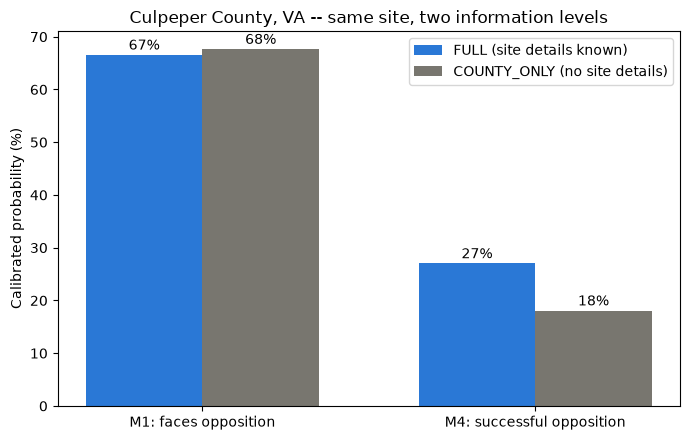

Site-level information narrows the estimate rather than just shifting it -- exactly
the point of scoring with a variant fit for what's known, instead of imputing.


In [5]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



from predict_location import print_prediction, predict

print("=" * 70)
print("Loudoun County, VA -- all four site inputs supplied")
print("=" * 70)
print_prediction(fips='51107', by_right=0, industrial_zoned=1, build_converted=0, project_year=2026)

print()
print("=" * 70)
print("Culpeper County, VA -- same site, two information levels")
print("=" * 70)
full = predict(fips='51047', by_right=1, industrial_zoned=1, build_converted=0, project_year=2026)
county_only = predict(fips='51047')

import numpy as np
models = ["M1", "M4"]
full_vals = [full['scores'][m]['cal_prob'] * 100 for m in models]
co_vals = [county_only['scores'][m]['cal_prob'] * 100 for m in models]

x = np.arange(len(models))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, full_vals, w, label='FULL (site details known)', color="#2a78d6")
ax.bar(x + w/2, co_vals, w, label='COUNTY_ONLY (no site details)', color="#78766f")
ax.set_xticks(x)
ax.set_xticklabels(['M1: faces opposition', 'M4: successful opposition'])
ax.set_ylabel('Calibrated probability (%)')
ax.set_title('Culpeper County, VA -- same site, two information levels')
ax.legend()
for i, v in enumerate(full_vals):
    ax.text(i - w/2, v + 1, f"{v:.0f}%", ha='center')
for i, v in enumerate(co_vals):
    ax.text(i + w/2, v + 1, f"{v:.0f}%", ha='center')
plt.tight_layout()
plt.show()
print("Site-level information narrows the estimate rather than just shifting it -- exactly")
print("the point of scoring with a variant fit for what's known, instead of imputing.")
